In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")
%matplotlib inline

In [3]:
# Path to your CSV file
file_path = "/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/SeamStress/dopt_results/benzene_s0/metrics.csv"  # <-- change this

# Load
df = pd.read_csv(file_path)

# Preview
print("Data preview:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

Data preview:


,strategy,n_sample,n_total,spearman,pearson,frobenius_abs,frobenius_rel,mse,knn_overlap_k5pct,knn_overlap_k10pct,knn_overlap_k20pct
0,single_ref,200,3657,0.828491,0.837031,8.471806,0.167247,0.001803,0.8445,0.8440,0.85225
1,multi_ref,200,3657,0.869913,0.867747,9.274372,0.183091,0.002161,0.8965,0.9055,0.91325



Columns:
['strategy', 'n_sample', 'n_total', 'spearman', 'pearson', 'frobenius_abs', 'frobenius_rel', 'mse', 'knn_overlap_k5pct', 'knn_overlap_k10pct', 'knn_overlap_k20pct']


/var/folders/_9/20wjp7894bs7kfh3bml0zbw40000gn/T/ipykernel_43420/2147580171.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/_9/20wjp7894bs7kfh3bml0zbw40000gn/T/ipykernel_43420/2147580171.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/_9/20wjp7894bs7kfh3bml0zbw40000gn/T/ipykernel_43420/2147580171.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


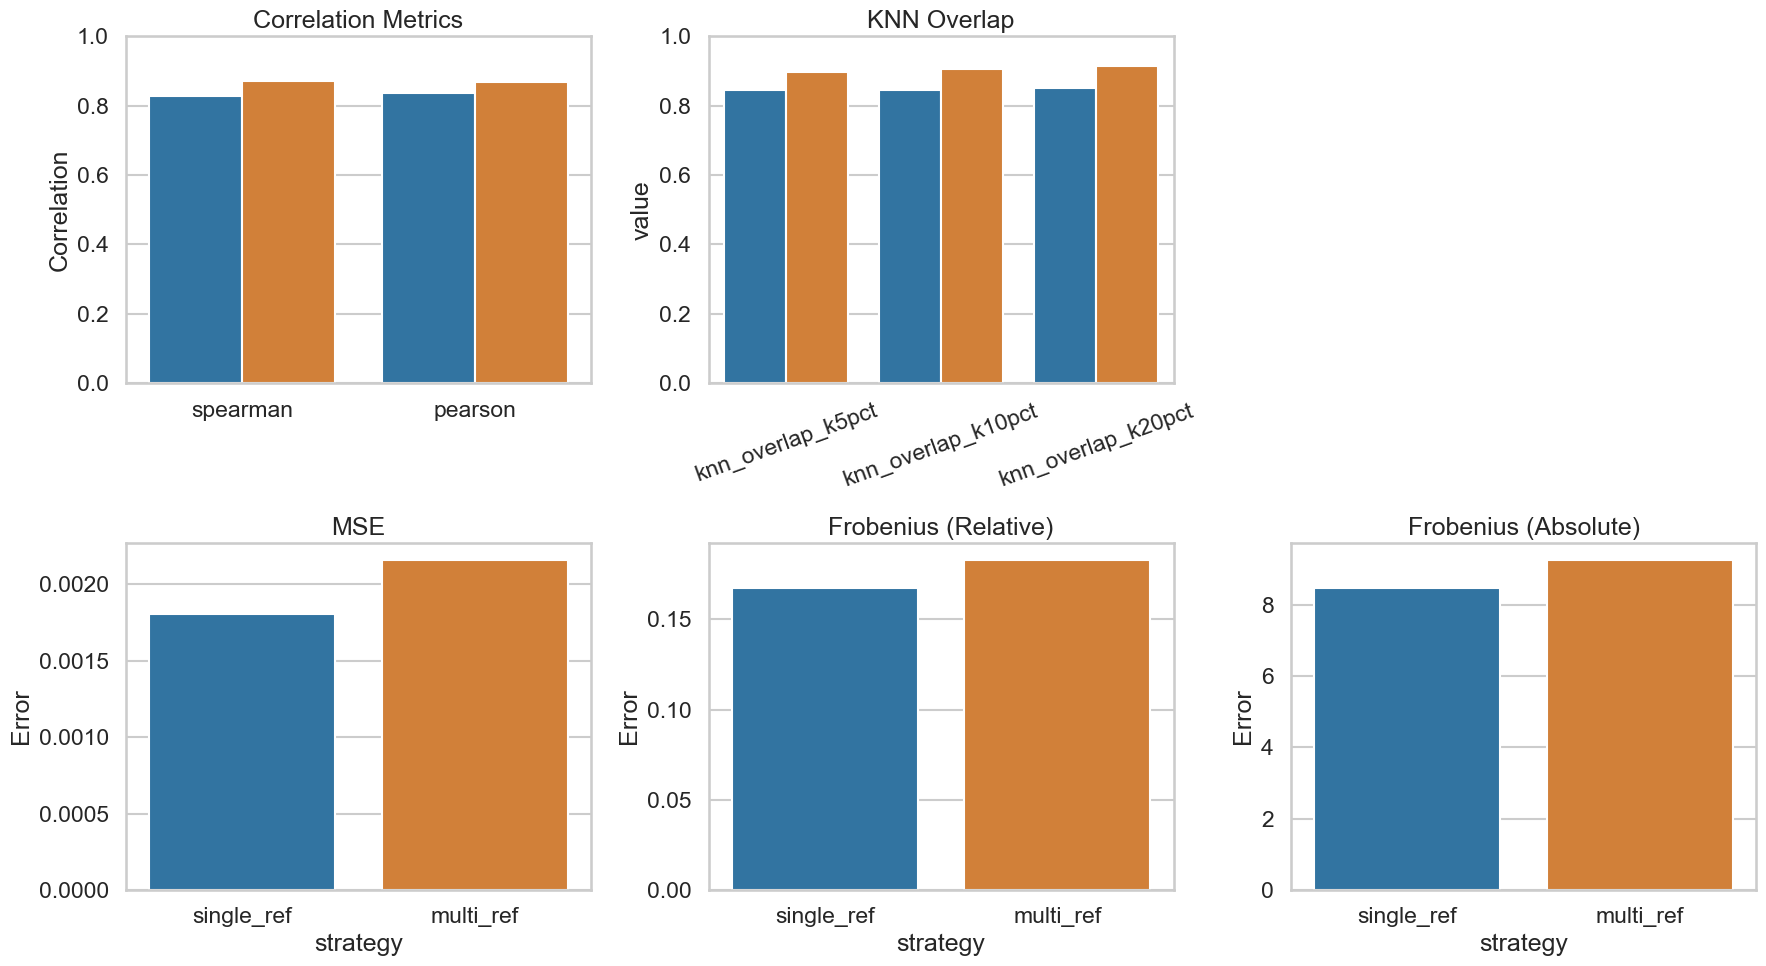

In [ ]:
# Fixed color mapping
palette = {
    "single_ref": "#1f77b4",  # blue
    "multi_ref": "#ff7f0e"    # orange
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# --- TOP ROW ---

# 1. Correlation metrics
metrics_corr = ["spearman", "pearson"]
df_corr = df.melt(
    id_vars="strategy",
    value_vars=metrics_corr,
    var_name="metric",
    value_name="value"
)

sns.barplot(
    data=df_corr,
    x="metric",
    y="value",
    hue="strategy",
    palette=palette,
    ax=axes[0]
)
axes[0].set_title("Correlation Metrics")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("")
axes[0].set_ylabel("Correlation")
axes[0].legend_.remove()


# 2. KNN overlap
metrics_knn = [
    "knn_overlap_k5pct",
    "knn_overlap_k10pct",
    "knn_overlap_k20pct"
]

df_knn = df.melt(
    id_vars="strategy",
    value_vars=metrics_knn,
    var_name="metric",
    value_name="value"
)

sns.barplot(
    data=df_knn,
    x="metric",
    y="value",
    hue="strategy",
    palette=palette,
    ax=axes[1]
)
axes[1].set_title("KNN Overlap")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend_.remove()


# 3. Empty
axes[2].axis("off")


# --- BOTTOM ROW ---

# 4. MSE
sns.barplot(data=df, x="strategy", y="mse", palette=palette, ax=axes[3])
axes[3].set_title("MSE")
axes[3].set_ylabel("Error")

# 5. Frobenius (relative)
sns.barplot(data=df, x="strategy", y="frobenius_rel", palette=palette, ax=axes[4])
axes[4].set_title("Frobenius (Relative)")
axes[4].set_ylabel("Error")

# 6. Frobenius (absolute)
sns.barplot(data=df, x="strategy", y="frobenius_abs", palette=palette, ax=axes[5])
axes[5].set_title("Frobenius (Absolute)")
axes[5].set_ylabel("Error")


# --- GLOBAL LEGEND (top-right) ---
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    frameon=False
)

# Layout
plt.tight_layout()
plt.show()